In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
# from photutils.aperture import EllipticalAperture
from photutils.datasets import make_noise_image
from photutils.background import MMMBackground
from astropy.modeling import models, fitting




In [3]:
!ls 


Coma galaxies dist.ipynb Coma_HST_FITS_view.ipynb gemini_data
Coma_Gal_Radial.ipynb    data                     HST Images
Coma_GCs_Position.ipynb  figures                  MW_GCs.xlsx


In [4]:
def load_gal_file(fn):
    # Load the CSV file
    df = pd.read_csv('../' + fn)

    # Display column names and the first few rows
    print("Columns in the catalog:")
    print(df.columns)

    print("\nPreview of the first few rows:")
    print(df.head())
    return df

gal_file = "Coma_Intracluster_GC/data/augmented_data_w_galnames.csv"
gal_df = load_gal_file(gal_file)


Columns in the catalog:
Index(['index', 'pointing', 'point_pos', 'x', 'y', 'galaxy type', 'duplicate',
       'vknownafterHectospec2007', 'sub_rating', 'ip_mag', 'ap_mag', 'RA',
       'Dec', 'radial', 'v', 'v_ref', 'z2007', 'Comments', 'RTP_comments',
       'COMAi', 'DEJ2000', 'EVIG2D', 'EVIGF', 'F814W', 'F814WG2D', 'F814WGF',
       'PAG2D', 'PAGF', 'RAJ2000', 'RFFG2D', 'RFFGF', 'ReG2D', 'ReGF',
       'SuBrG2D', 'SuBrGF', 'SuBrmG2D', 'SuBrmGF', 'e_F814WG2D', 'e_F814WGF',
       'e_PAG2D', 'e_PAGF', 'e_ReG2D', 'e_ReGF', 'e_ellG2D', 'e_ellGF',
       'e_nG2D', 'e_nGF', 'ellG2D', 'ellGF', 'nG2D', 'nGF', 'recno',
       'ReG2D_arcsec', 'ReGF_arcsec', 'gal_name'],
      dtype='object')

Preview of the first few rows:
   index  pointing      point_pos       x     y galaxy type duplicate  \
0    463      63.0          outer  2135.0  1146           4       NaN   
1    390      25.0          inner  1199.0   389           1       NaN   
2     69       8.0   Intermediate  3350.0  3138        

In [5]:
gal_name = "NGC 4874"
gal_row = gal_df[gal_df["gal_name"] == gal_name].iloc[0]
target_coord = (gal_row["RA"], gal_row["Dec"])

target_coord


(194.8988, 27.9593)

In [6]:
from astropy.coordinates import SkyCoord
from astropy import units as u

target = SkyCoord(ra=gal_row["RA"] * u.deg, dec=gal_row["Dec"] * u.deg)

target


<SkyCoord (ICRS): (ra, dec) in deg
    (194.8988, 27.9593)>

In [7]:
!ls 'HST Images'

fits_paths = 'HST Images'

Coma_2-3_g_10.fits Coma_2-3_i_10.fits


In [8]:
from pathlib import Path

fits_paths = list(Path("../Coma_Intracluster_GC/regions").rglob("*.fits"))

fits_paths


[PosixPath('../Coma_Intracluster_GC/regions/combined_mosaic.fits'),
 PosixPath('../Coma_Intracluster_GC/regions/combined_mosaic_NGC_4874.fits'),
 PosixPath('../Coma_Intracluster_GC/regions/combined_mosaic_NGC_4889.fits'),
 PosixPath('../Coma_Intracluster_GC/regions/OS17/h_v59_F475W_ivm_drz_cl_ver2.fits'),
 PosixPath('../Coma_Intracluster_GC/regions/OS17/h_v59_F814W_ivm_drz_cl_ver2.fits'),
 PosixPath('../Coma_Intracluster_GC/regions/OS21/h_v63_F814W_ivm_drz_cl_ver2.fits'),
 PosixPath('../Coma_Intracluster_GC/regions/OS21/h_v63_F475W_ivm_drz_cl_ver2.fits'),
 PosixPath('../Coma_Intracluster_GC/regions/1-1/h_v01_F814W_ivm_drz_cl_ver2.fits'),
 PosixPath('../Coma_Intracluster_GC/regions/1-1/h_v01_F475W_ivm_drz_cl_ver2.fits'),
 PosixPath('../Coma_Intracluster_GC/regions/3-2/h_v16_F814W_ivm_drz_cl_ver2.fits'),
 PosixPath('../Coma_Intracluster_GC/regions/3-2/h_v16_F475W_ivm_drz_cl_ver2.fits'),
 PosixPath('../Coma_Intracluster_GC/regions/3-5/h_v19_F475W_ivm_drz_cl_ver2.fits'),
 PosixPath('../Com

In [9]:
from astropy.io import fits
from astropy.wcs import WCS


def get_fits_image_wcs_and_header_data(image_path, hdu_index=1):
    # === 1. Load image ===
    print(image_path)
    with fits.open(image_path, mode='update') as hdul:
        hdr = hdul[hdu_index].header  # or [0] depending on your image
        for key in list(hdr.keys()):
            if key.startswith(('A_', 'B_', 'AP_', 'BP_', 'A_ORDER', 'B_ORDER')):
                del hdr[key]
        hdul.flush()

    hdul = fits.open(image_path)
    data = hdul[hdu_index].data  # Image data could be in various HDU, but normally 1
    header = hdul[hdu_index].header
    wcs = WCS(header)  # Adjust HDU if needed
    hdul.close()
    return data, wcs, header


def target_in_fits(fits_path, target_coord):
    with fits.open(fits_path) as hdul:
        try:
            w = WCS(hdul[1].header) if hdul[1].data is not None else WCS(hdul[0].header)
            ny, nx = hdul[1].data.shape
        except Exception:
            return False

        # Get pixel position
        try:
            px, py = w.world_to_pixel(SkyCoord(*target_coord, unit='deg'))
        except Exception:
            return False

        return (0 <= px < nx) and (0 <= py < ny)


In [10]:
for path in fits_paths:
    get_fits_image_wcs_and_header_data(path)
    if target_in_fits(path, target_coord):
        print(f"Galaxy {gal_name} is in: {path}")


../Coma_Intracluster_GC/regions/combined_mosaic.fits
../Coma_Intracluster_GC/regions/combined_mosaic_NGC_4874.fits
../Coma_Intracluster_GC/regions/combined_mosaic_NGC_4889.fits
../Coma_Intracluster_GC/regions/OS17/h_v59_F475W_ivm_drz_cl_ver2.fits


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


../Coma_Intracluster_GC/regions/OS17/h_v59_F814W_ivm_drz_cl_ver2.fits
../Coma_Intracluster_GC/regions/OS21/h_v63_F814W_ivm_drz_cl_ver2.fits
../Coma_Intracluster_GC/regions/OS21/h_v63_F475W_ivm_drz_cl_ver2.fits
../Coma_Intracluster_GC/regions/1-1/h_v01_F814W_ivm_drz_cl_ver2.fits
../Coma_Intracluster_GC/regions/1-1/h_v01_F475W_ivm_drz_cl_ver2.fits
../Coma_Intracluster_GC/regions/3-2/h_v16_F814W_ivm_drz_cl_ver2.fits
../Coma_Intracluster_GC/regions/3-2/h_v16_F475W_ivm_drz_cl_ver2.fits
../Coma_Intracluster_GC/regions/3-5/h_v19_F475W_ivm_drz_cl_ver2.fits
Galaxy NGC 4874 is in: ../Coma_Intracluster_GC/regions/3-5/h_v19_F475W_ivm_drz_cl_ver2.fits
../Coma_Intracluster_GC/regions/3-5/h_v19_F814W_ivm_drz_cl_ver2.fits
Galaxy NGC 4874 is in: ../Coma_Intracluster_GC/regions/3-5/h_v19_F814W_ivm_drz_cl_ver2.fits
../Coma_Intracluster_GC/regions/3-5/jb2i01020_drc.fits
Galaxy NGC 4874 is in: ../Coma_Intracluster_GC/regions/3-5/jb2i01020_drc.fits
../Coma_Intracluster_GC/regions/OS3/h_v45_F475W_ivm_drz_cl_

In [11]:
from pathlib import Path

fits_paths = list(Path("HST Images").rglob("*.fits"))

fits_paths

[PosixPath('HST Images/Coma_2-3_g_10.fits'),
 PosixPath('HST Images/Coma_2-3_i_10.fits')]

In [12]:
for fits_path in fits_paths:
    with fits.open(fits_path) as hdul:
        data = hdul[1].data if hdul[1].data is not None else hdul[0].data
        header = hdul[1].header if hdul[1].data is not None else hdul[0].header
        wcs = WCS(header)


In [13]:
# Convert 10×Re from arcsec to pixels using pixel scale from the FITS header
from astropy.wcs.utils import proj_plane_pixel_scales

pixscale_deg = proj_plane_pixel_scales(wcs)[0]  # degrees/pixel
pixscale_arcsec = pixscale_deg * 3600  # arcsec/pixel

pixscale = np.abs(header["CD1_1"]) * 3600  # arcsec/pixel
print(f'Pixscale (arcsec): {pixscale_arcsec:.3f}')
re_arcsec = gal_row['ReGF_arcsec']
print(f'GF Re (arcsec):{re_arcsec:.3f}')
pa_theta = gal_row['PAGF']
ellipticity = gal_row['ellGF']
print(f'PA (deg): {pa_theta}')
print(f'Ellipticity: {ellipticity}')
r_eff = int(re_arcsec / pixscale_arcsec)

# cutout_size = (int((10 * re_arcsec) / pixscale) * 2)  # ensure symmetric
cutout_size_pixels = 10 * r_eff
cutout = Cutout2D(data, position=target, size=(cutout_size_pixels, cutout_size_pixels), wcs=wcs)
print(f'Cutout size: {cutout_size:.2f}')
# cutout = Cutout2D(data, position=target, size=cutout_size, wcs=wcs)

cutout_data = np.copy(cutout.data)

# Mask non-finite values
fit_mask = np.isfinite(cutout_data) & (cutout_data > 0)
cutout_data_clean = np.where(fit_mask, cutout_data, 0.0)
cutout_data_clean = cutout_data_clean.astype(float)

# Optional: also mask out zero background if it’s really large
# cutout_data[cutout_data < threshold] = 0


Pixscale (arcsec): 0.050
GF Re (arcsec):7.135
PA (deg): -67.2
Ellipticity: 0.057


NoOverlapError: Arrays do not overlap.

In [14]:
print("Cutout shape:", cutout_data_clean.shape)
print("Min:", np.nanmin(cutout_data_clean), "Max:", np.nanmax(cutout_data_clean))
print("Any nonfinite?", np.any(~np.isfinite(cutout_data_clean)))

NameError: name 'cutout_data_clean' is not defined

In [15]:
import warnings
import matplotlib.patches as mpatches

# Double Sérsic Fit (2D Model)

y, x = np.mgrid[:cutout_data_clean.shape[0], :cutout_data_clean.shape[1]]

sersic1 = models.Sersic2D(amplitude=1, r_eff=r_eff/1.5, n=4,
                    x_0=cutout_data_clean.shape[1]/2, y_0=cutout_data_clean.shape[0]/2,
                    ellip=ellipticity, theta=pa_theta) 
sersic2 = models.Sersic2D(amplitude=0.5, r_eff=r_eff, n=1,
                    x_0=cutout_data_clean.shape[1]/2, y_0=cutout_data_clean.shape[0]/2,
                    ellip=ellipticity, theta=pa_theta+0.2)

# Bounds to prevent instability
for s in [sersic1, sersic2]:
    s.amplitude.bounds = (0, None)       # positive only
    s.r_eff.bounds = (1, nx / 2)         # >0 and smaller than image
    s.n.bounds = (0.3, 8)                # physical range
    s.x_0.bounds = (0, nx)
    s.y_0.bounds = (0, ny)
    s.ellip.bounds = (0.0, 0.9)          # avoid degenerate shapes
    s.theta.bounds = (-np.pi, np.pi)

init = sersic1 + sersic2

fitter = fitting.LevMarLSQFitter()

# Optional: ignore warnings from fitting
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    model = fitter(init, x, y, cutout_data_clean)

model_image = model(x, y)
residual = cutout_data_clean - model_image




NameError: name 'cutout_data_clean' is not defined

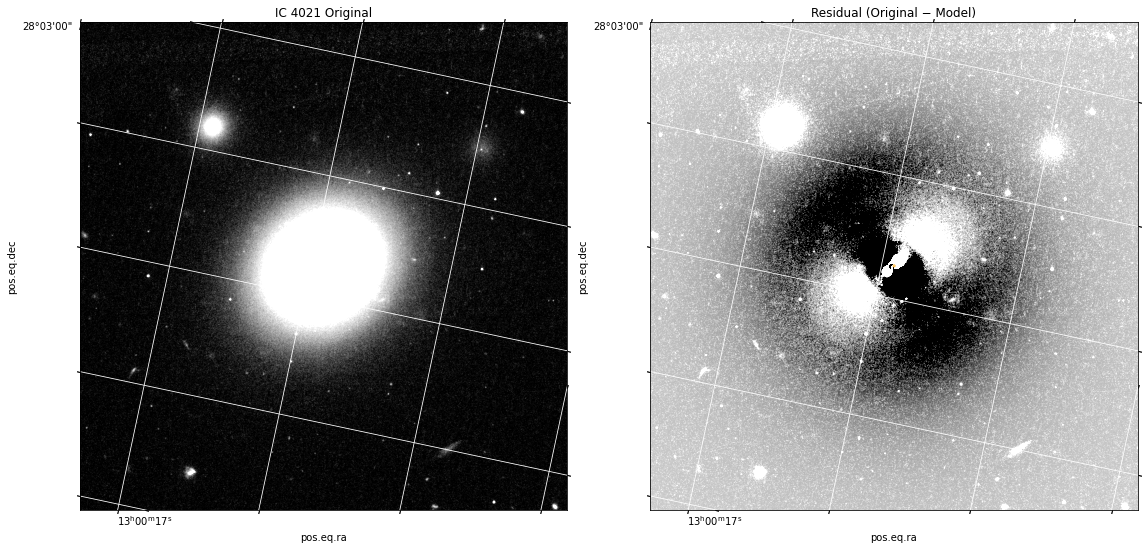

In [206]:
# Plot original and residual
from matplotlib.colors import LogNorm, Normalize
from scipy.stats import norm
from astropy.visualization import ImageNormalize, AsinhStretch, SqrtStretch

fig, axes = plt.subplots(1, 2, figsize=(16, 8), subplot_kw={'projection': cutout.wcs})

# Determine pixel center (should match model x0, y0)
ny, nx = cutout_aligned.shape
x0 = nx / 2
y0 = ny / 2

# Sérsic effective radius in pixels (use first component if using 2)
r_eff_pix = model[0].r_eff.value  # if using a compound model: model[0] and model[1]

# Create and add circle
circle = mpatches.Circle((x0, y0), r_eff_pix,
                         edgecolor='orange', facecolor='none', lw=2, alpha=0.8,
                         transform=axes[1].get_transform('pixel'))

vmin = np.percentile(cutout_data_clean, 5)
vmax = np.percentile(cutout_data_clean, 95)
norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(0.4))

axes[0].imshow(cutout_data_clean, origin='lower', cmap='gray', norm=norm)
axes[0].set_title(f"{gal_name} Original")
axes[0].coords.grid(True, color='white')

vmin = np.percentile(residual, 5)
vmax = np.percentile(residual, 95)
norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(0.4))

axes[1].imshow(residual, origin='lower', cmap='gray', norm=norm)
axes[1].set_title("Residual (Original − Model)")
axes[1].coords.grid(True, color='white')
axes[1].add_patch(circle)

plt.tight_layout()
plt.show()


In [195]:
from reproject import reproject_interp
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales

# Image center in world coords
ny, nx = cutout_data_clean.shape
center_world = cutout.wcs.pixel_to_world(nx / 2, ny / 2)

# Pixel scale (assumes square pixels)
pixscale_deg = proj_plane_pixel_scales(cutout.wcs)[0]  # degrees/pixel

# Create a north-up aligned WCS centered on the cutout
aligned_wcs = WCS(naxis=2)
aligned_wcs.wcs.crval = [center_world.ra.deg, center_world.dec.deg]
aligned_wcs.wcs.crpix = [nx / 2, ny / 2]
aligned_wcs.wcs.cdelt = [pixscale_deg, pixscale_deg]  # No rotation
aligned_wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]

# Reproject both images to this WCS
cutout_aligned, _ = reproject_interp((cutout_data_clean, cutout.wcs), aligned_wcs, shape_out=(ny, nx))
residual_aligned, _ = reproject_interp((residual, cutout.wcs), aligned_wcs, shape_out=(ny, nx))


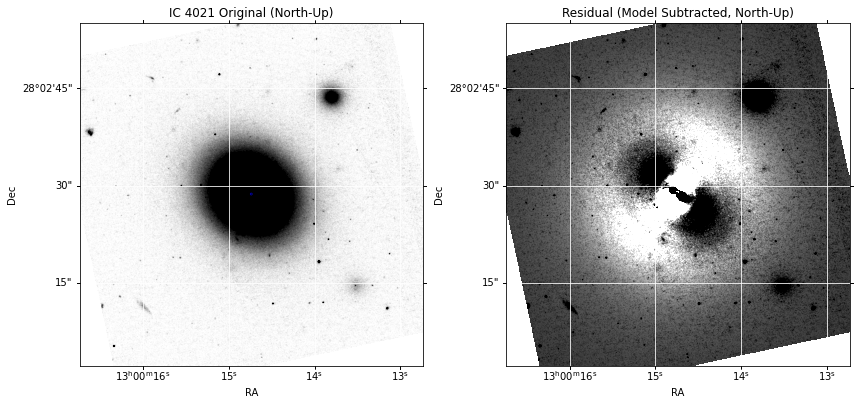

In [203]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={'projection': aligned_wcs})

# Determine pixel center (should match model x0, y0)
ny, nx = cutout_aligned.shape
x0 = nx / 2
y0 = ny / 2

# Sérsic effective radius in pixels (use first component if using 2)
r_eff_pix = model[0].r_eff.value  # if using a compound model: model[0] and model[1]

# Create and add circle
circle = mpatches.Circle((x0, y0), r_eff_pix,
                         edgecolor='blue', facecolor='none', lw=2, alpha=0.8,
                         transform=axes[0].get_transform('pixel'))

vmin = np.percentile(cutout_data_clean, 5)
vmax = np.percentile(cutout_data_clean, 95)
norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(0.6))

axes[0].imshow(cutout_aligned, origin='lower', norm=norm, cmap='gray_r')
axes[0].set_title(f"{gal_name} Original (North-Up)")
axes[0].coords.grid(True, color='white')
axes[0].coords[0].set_axislabel('RA')
axes[0].coords[1].set_axislabel('Dec')
axes[0].invert_xaxis()
axes[0].add_patch(circle)

vmin = np.percentile(residual, 5)
vmax = np.percentile(residual, 95)
norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(0.6))

axes[1].imshow(residual_aligned, origin='lower', norm=norm, cmap='gray_r')
axes[1].set_title("Residual (Model Subtracted, North-Up)")
axes[1].coords.grid(True, color='white')
axes[1].coords[0].set_axislabel('RA')
axes[1].coords[1].set_axislabel('Dec')
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()


In [2]:
from astropy.io import fits
from astropy.wcs import WCS
from skimage import exposure
import matplotlib.pyplot as plt
import astropy.units as u
import numpy as np
from astropy.coordinates import SkyCoord
from matplotlib.patches import Circle
import pandas as pd
from pprint import pprint 
from astropy.visualization import astropy_mpl_style, AsinhStretch, ImageNormalize
# from astropy.visualization.wcsaxes import SlicedLowLevelWCS
from reproject import reproject_interp

# import seaborn as sns
# %ls data

# set the default fontsize
fs = 16
filename = 'j96f03010_drz.fits'
# Path to FITS file
fits_file_path = f'HST data/{filename}'

# Open the FITS file
with fits.open(fits_file_path) as hdul:
    # The primary HDU contains the image data
    image_data = hdul[0].data
    
    # The header contains the WCS information
    header = hdul[0].header
    wcs = WCS(header)

print(header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  DATE    = '2024-12-27'         / date this file was written (yyyy-mm-dd)        COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H                                                                                 TELESCOP= 'HST'                / telescope used to acquire data                 INSTRUME= 'ACS   '             / identifier for instrument used to acquire data                                                                                               / DATA DESCRIPTION KEYWORDS                                                                               

In [3]:
# import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# from astropy.io import fits
# from astropy.visualization import ImageNormalize, AsinhStretch
# import numpy as np


min_val = 0.1
max_val = 99.8

# Bias and contrast settings to apply (9 combinations)
min_pc_values = np.linspace(0.2, 2, 3)
max_pc_values = np.linspace(99.6, 99.9, 3)
norm_values = np.linspace(0.05, 0.85, 9)
print(min_val, max_val, norm_values)

# Set up the figure and a 3x3 grid using GridSpec
fig = plt.figure(figsize=(11, 8))
gs = GridSpec(3, 3, figure=fig)

# Loop over bias and contrast combinations and plot each version of the image
# for i, min_val in enumerate(min_pc_values):
for i in range(0,3):
#     for j, max_val in enumerate(max_pc_values):
    for j in range(0,3):
        idx = (i*3)+j
        
        norm_value = float(norm_values[idx])
#         print(idx, norm_value)
        # Apply asinh scaling using ImageNormalize and AsinhStretch
        norm = ImageNormalize(vmin=np.percentile(image_data, min_val), 
                              vmax=np.percentile(image_data, max_val), 
                              stretch=AsinhStretch(norm_value))
        
        print(f'row: {i:<1d}, col: {j:<1d}, min: {min_val:<5.2f}, max: {max_val:<5.2f}, norm: {norm_value:<5.2f}')
        # Get the subplot for this combination
        ax = fig.add_subplot(gs[i, j])

        # Plot the image with the adjusted data
        im = ax.imshow(image_data, origin='lower', cmap='gray_r', norm=norm)

        # Set the title to show the values used
#         ax.set_title(f'Min={min_val}, Max={max_val}', fontsize=10)
        ax.set_title(f'Norm={norm_value}', fontsize=10)

        # Remove the axis ticks for clarity
        ax.set_xticks([])
        ax.set_yticks([])

# Add an overall colorbar
fig.colorbar(im, ax=fig.get_axes(), orientation='vertical', fraction=0.03, pad=0.04)

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the figure
plt.show()


0.1 99.8 [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85]


TypeError: unsupported operand type(s) for -: 'NoneType' and 'NoneType'

<Figure size 792x576 with 0 Axes>

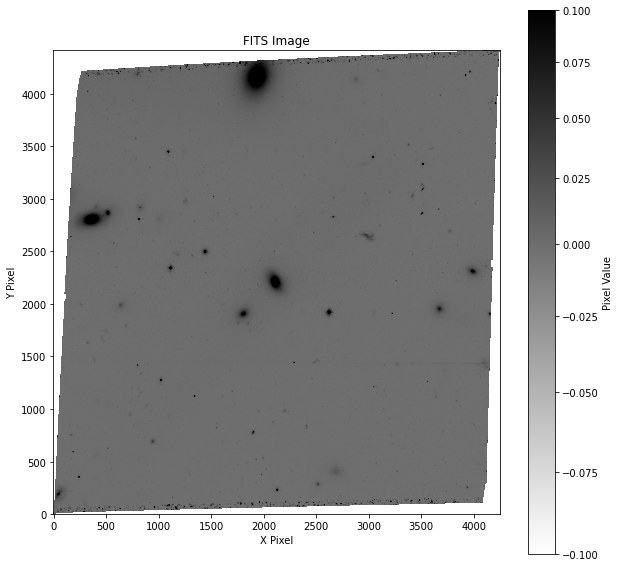

In [4]:
import matplotlib.pyplot as plt
from astropy.io import fits

# Load the FITS file
hdul = fits.open(fits_file_path)

# Get the image data (usually in the first extension)
image_data = hdul[1].data
hdul.close()

norm = ImageNormalize(vmin=np.percentile(image_data, 2), 
                      vmax=np.percentile(image_data, 99.6), 
                      stretch=AsinhStretch(0.75))
# Display the image
plt.figure(figsize=(10, 10))
plt.imshow(image_data, cmap='gray_r', origin='lower', norm=norm)
plt.colorbar(label='Pixel Value')
plt.title('FITS Image')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.show()


In [8]:
# define a couple of helper functions and utilities used repeatedly
def bin_init(i, j, magbins):
    # Calculate the index for the bin
    bindex = j + (i * cols)

#     # Check if bindex is within the number of bins minus 1 (it should be!)
#     if bindex >= len(mag_bins) - 1:
#         return False, []

    # Define the bin start and end
    bin_start = mag_bins[bindex]
    bin_end = mag_bins[bindex + 1]

    return bindex, bin_start, bin_end

def get_wcs_range(wcs_1, image_data_1):
    
    # Determine the image extent in world coordinates
    wcs_world_extent = wcs_1.pixel_to_world([0, image_data_1.shape[1]], [0, image_data_1.shape[0]])

    # Determine the min and max coordinates in world coordinates
#     ra_min, ra_max = wcs_world_extent[0].value.min(), wcs_world_extent[0].value.max()
#     dec_min, dec_max = wcs_world_extent[1].value.min(), wcs_world_extent[1].value.max()
    
            
#     # Set desired limits in WCS (RA, Dec)
#     ra_min, ra_max = 195.28, 194.74  # RA limits in degrees
#     dec_min, dec_max = 27.805, 28.19  # Dec limits in degrees
    
    return ra_min, ra_max, dec_min, dec_max

# import matplotlib.pyplot as plt
# from astropy.wcs import WCS
# from astropy.io import fits
# import numpy as np

def decimal_to_sexagesimal(decimal_angle):
    """
    Convert a decimal angle to sexagesimal format.

    Parameters:
    decimal_angle (float): Decimal degree value to be converted.

    Returns:
    tuple: A tuple representing (degrees, minutes, seconds)
    """
    # Create an Angle object from the input decimal degrees
    angle = Angle(decimal_angle, unit=u.deg)
    
    # Extract degrees (integer part of the angle)
    degrees = int(angle.deg)
    
    # Calculate fractional part of degrees to convert to sexagesimal minutes
    fractional_degrees = angle.deg - degrees
    sexagesimal_minutes = fractional_degrees * 60
    
    # Extract the integer part of sexagesimal minutes
    minutes = int(sexagesimal_minutes)
    
    # Calculate fractional part of minutes to convert to sexagesimal seconds
    fractional_minutes = sexagesimal_minutes - minutes
    sexagesimal_seconds = fractional_minutes * 60
    
    return degrees, minutes, sexagesimal_seconds

def sexagesimal_to_decimal(degrees, minutes, seconds):
    """
    Convert an angle from sexagesimal format (degrees, minutes, seconds) to decimal format.

    Parameters:
    degrees (int or float): Degrees part of the angle.
    minutes (int or float): Minutes part of the angle.
    seconds (int or float): Seconds part of the angle.

    Returns:
    float: The decimal representation of the angle.
    """
    # Convert the sexagesimal angle to decimal
    decimal_angle = degrees + (minutes / 60) + (seconds / 3600)
    print(f"{degrees}° {minutes}' {seconds}'' in decimal is: {decimal_angle:.6f} degrees")
    
    return decimal_angle

def add_scale_bar(ax, wcs, length_arcsec, label="1 arcmin", color='white', fontsize=12):
    """
    Add a scale bar (line) to a WCS-based Matplotlib image plot.

    Parameters:
    ax (matplotlib.axes._subplots.AxesSubplot): The axes object where the image is plotted.
    wcs (astropy.wcs.WCS): The WCS object for the image.
    length_arcsec (float): The length of the scale bar in arcseconds.
    label (str): The text label for the scale bar (default is '1 arcmin').
    color (str): Color of the scale bar and text (default is 'white').
    fontsize (int): Font size of the label (default is 12).
    """
    # Get the center of the image in pixel coordinates
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    center_x = (0.1 * (xlim[1] - xlim[0])) + xlim[0]  # Position scale bar at 10% of the plot width
    center_y = (0.1 * (ylim[1] - ylim[0])) + ylim[0]  # Position scale bar at 10% of the plot height
    
    # Convert the scale bar length from arcseconds to pixel length using the WCS
    pixel_scale = np.abs(wcs.wcs.cd[0][0]) * 3600  # Pixel scale in arcseconds per pixel
    length_pixels = length_arcsec / pixel_scale  # Length in pixels

    # Plot the scale bar as a line
    ax.plot([center_x, center_x + length_pixels], [center_y, center_y],
            color=color, lw=2, transform=ax.get_transform('pixel'))
    ax.plot([center_x, center_x], [center_y-(length_pixels/20), center_y+(length_pixels/20)],
            color=color, lw=2, transform=ax.get_transform('pixel'))
    ax.plot([center_x+length_pixels, center_x+length_pixels], [center_y-(length_pixels/20), center_y+(length_pixels/20)],
            color=color, lw=2, transform=ax.get_transform('pixel'))

    # Add a label to the scale bar
    ax.text(center_x + length_pixels / 2, center_y - 0.02 * (ylim[1] - ylim[0]),
            label, color=color, fontsize=fontsize, ha='center', va='top',
            transform=ax.get_transform('pixel'))

def get_angular_sep(d: float, D: float):
    """
    Get the angular separation in arcsec
    
    Parameters:
    d: spatial distance in parsecs
    D: radial distance to object, also in parsecs
    
    Returns: 
    angular seperation in arcseconds
    """
    return (d/D)*(180/np.pi)*3600

def get_spatial_dist(theta: float, D: float,):
    """
    Get the spatial distance in parsecs
    
    Parameters:
    Theta: anglular seperation in arcseconds
    D: radial distance to object, in parsecs
    
    Returns:
    spatial distance in parsecs
    """
    return (theta/3600)*(np.pi/180)*D


In [9]:
# Apply Astropy's default plot style
plt.style.use(astropy_mpl_style)

fits_file_path = ['HST data/j96f03010_drz.fits']
hdu = []
wcs = []
image_data = []

for i, file in enumerate(fits_file_path):
    print(i, ", ", file)
    # Path to FITS file
#     fits_file_path[0] = 'HST_fits/h_v16_F814W_ivm_drz_cl_ver2.fits'

    # Open the FITS file
    hdu.append(fits.open(file)[1])
#     print(hdu[i])

    # Extract the WCS information
    wcs.append(WCS(hdu[i].header))

    # Load the image data
    image_data.append(hdu[i].data)
    
    if i!=0:
        # Reproject the second image to the WCS of the first image
        image_data[i], footprint = reproject_interp((image_data[i], wcs[i]), wcs[0], shape_out=image_data[0].shape)



0 ,  HST data/j96f03010_drz.fits


In [10]:
# print(hdu.header)

TypeError: 'NoneType' object is not subscriptable

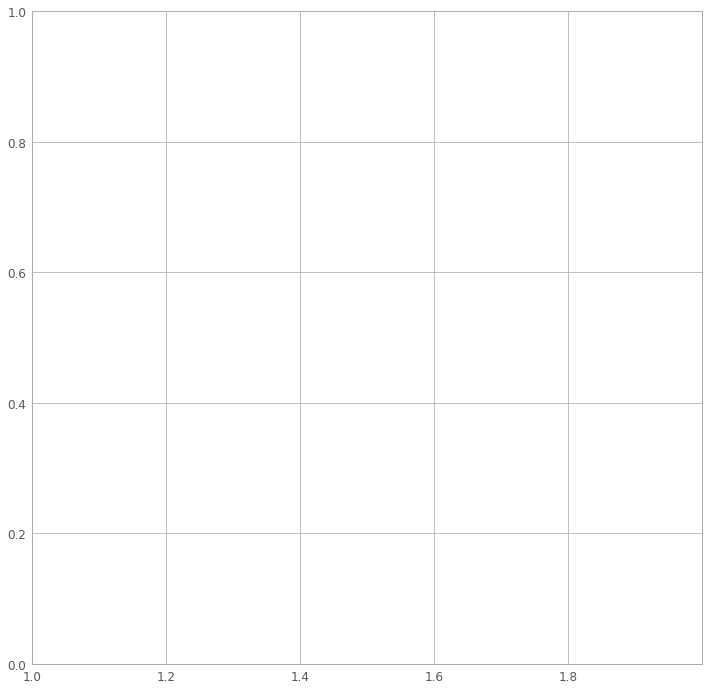

In [13]:

# Create a figure and a WCS-aware axis
fig, ax = plt.subplots(subplot_kw={'projection': wcs[0]}, figsize=(12,12))

for i, file in enumerate(fits_file_path):
    # Apply asinh scaling using ImageNormalize and AsinhStretch
#     norm = ImageNormalize(stretch=AsinhStretch(), vmin=np.percentile(image_data[i], 0.3), 
#                           vmax=np.percentile(image_data, 99.6))
    #                       vmin=np.min(image_data), vmax=np.max(image_data))
    
    # Display the image
    ax.imshow(image_data[i], origin='lower', cmap='gray_r', 
              vmin=np.percentile(image_data[i], 5), 
              vmax=np.percentile(image_data[i], 95))

# Set the axis labels to RA/Dec
ax.set_xlabel('Right Ascension (J2000)')
ax.set_ylabel('Declination (J2000)')

# Set plot labels and title
plt.xlabel('RA (degrees)', fontsize=14)
plt.ylabel('Dec (degrees)', fontsize=14)
plt.title(f'{fits_file_path}', fontsize=16)

# # ra_min, ra_max = 195.10, 194.97  # RA limits in degrees
# # dec_min, dec_max = 27.94, 28.01  # Dec limits in degrees

# pix_min = wcs[0].world_to_pixel_values(ra_min, dec_min)
# pix_max = wcs[0].world_to_pixel_values(ra_max, dec_max)

# # Set pixel limits directly
# ax.set_xlim(pix_min[0], pix_max[0])
# ax.set_ylim(pix_min[1], pix_max[1])  

# # Display the image with asinh scaling
# plt.imshow(image_data, cmap='gray', origin='lower', norm=norm)
# plt.colorbar()  # Optional: Show a color bar
# plt.show()

# Display the plot
plt.show()

0 ,  HST data/j96f03010_drz.fits


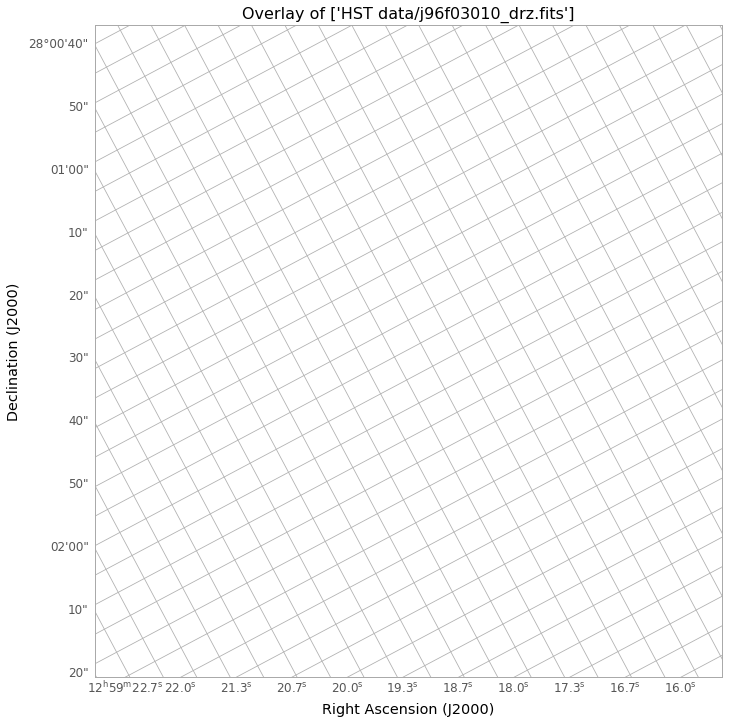

In [14]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp
import numpy as np
from astropy.visualization import astropy_mpl_style

# Apply Astropy's default plot style
plt.style.use(astropy_mpl_style)

fits_file_path = ['HST data/j96f03010_drz.fits']
hdu = []
wcs = []
image_data = []

for i, file in enumerate(fits_file_path):
    print(i, ", ", file)

    # Open the FITS file and extract the relevant extension
    hdu.append(fits.open(file)[1])

    # Extract the WCS information
    wcs.append(WCS(hdu[i].header))

    # Load the image data
    image_data.append(hdu[i].data)
    
    if i != 0:
        # Reproject the second image to the WCS of the first image
        image_data[i], footprint = reproject_interp((image_data[i], wcs[i]), wcs[0], shape_out=image_data[0].shape)

# Create a figure and a WCS-aware axis
fig, ax = plt.subplots(subplot_kw={'projection': wcs[0]}, figsize=(12,12))

# Loop through images and overlay with transparency
for i, file in enumerate(fits_file_path):
    # Adjust transparency for the second image
    alpha = 1 if i == 0 else 1
    
    # Display the image with transparency
    ax.imshow(image_data[i], origin='lower', cmap='gray_r', alpha=alpha,
              vmin=np.percentile(image_data[i], 5), 
              vmax=np.percentile(image_data[i], 95))

# Set axis labels to RA/Dec
ax.set_xlabel('Right Ascension (J2000)')
ax.set_ylabel('Declination (J2000)')

# Set plot labels and title
plt.title(f'Overlay of {fits_file_path}', fontsize=16)

# Optionally, set limits for RA/Dec in degrees (you can adjust/remove this to check full overlap)
ra_min, ra_max = 195.10, 194.97  # RA limits in degrees
dec_min, dec_max = 27.94, 28.01  # Dec limits in degrees

pix_min = wcs[0].world_to_pixel_values(ra_min, dec_min)
pix_max = wcs[0].world_to_pixel_values(ra_max, dec_max)

# Set pixel limits directly (you can comment these lines to see the entire images)
# ax.set_xlim(pix_min[0], pix_max[0])
# ax.set_ylim(pix_min[1], pix_max[1])

pix_lim = ax.get_xlim()
ax.set_xlim(pix_lim[1], pix_lim[0])

# Adjust the ticks and tick labels if necessary
# ax.coords[0].set_major_formatter('dd:mm')
# ax.coords[1].set_major_formatter('dd:mm')
# ax.tick_params(axis='both', which='major', labelsize=11, direction='out', length=3)
# Explicitly set the number of ticks
ax.coords[0].set_ticks(spacing=10 * u.arcsec)  # Set 5 RA ticks with 0.01 degree spacing
ax.coords[1].set_ticks(spacing=10 * u.arcsec)  # Set 5 Dec ticks with 0.01 degree spacing

# Display the plot
plt.show()


In [16]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp
import numpy as np
from astropy.visualization import astropy_mpl_style

# Apply Astropy's default plot style
plt.style.use(astropy_mpl_style)

# File paths to the FITS files
fits_file_path = 'HST data/j96f03010_drz.fits'

# Open the FITS file
with fits.open(fits_file_path) as hdul:
    # The primary HDU contains the image data
    image_data = hdul[1].data
    
    # The header contains the WCS information
    header = hdul[1].header
    wcs = WCS(header)
    
    hdul.info()
    


Filename: HST data/j96f03010_drz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     820   ()      
  1  SCI           1 ImageHDU        82   (4248, 4418)   float32   
  2  WHT           1 ImageHDU        44   (4248, 4418)   float32   
  3  CTX           1 ImageHDU        37   (4248, 4418)   int32   
  4  HDRTAB        1 BinTableHDU    595   8R x 293C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, 8A, 9A, 7A, 18A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, 8A, 23A, D, D, D, D, K, K, K, 8A, K, 23A, 9A, 20A, K, 4A, K, K, K, K, K, K, 23A, D, D, D, D, K, K, 3A, 3A, 4A, 4A, L, D, D, D, 3A, 1A, K, D, D, D, D, D, 4A, 4A, 12A, 12A, 23A, 8A, 23A, 10A, 10A, D, D, 3A, 3A, 23A, 4A, 8A, 7A, 23A, D, K, D, 6A, 9A, 8A, D, D, L, 9A, 18A, 3A, K, 7A, 5A, 3A, D, 13A, 8A, 4A, 3A, L, K, L, K, L, K, K, D, D, D, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, 23A, L, 1A, 3A, 1A, D, 3A, 6A, K, D, D, D, D, D, D, D, D, D, D, 23A, D, D, D, D, 3A, D

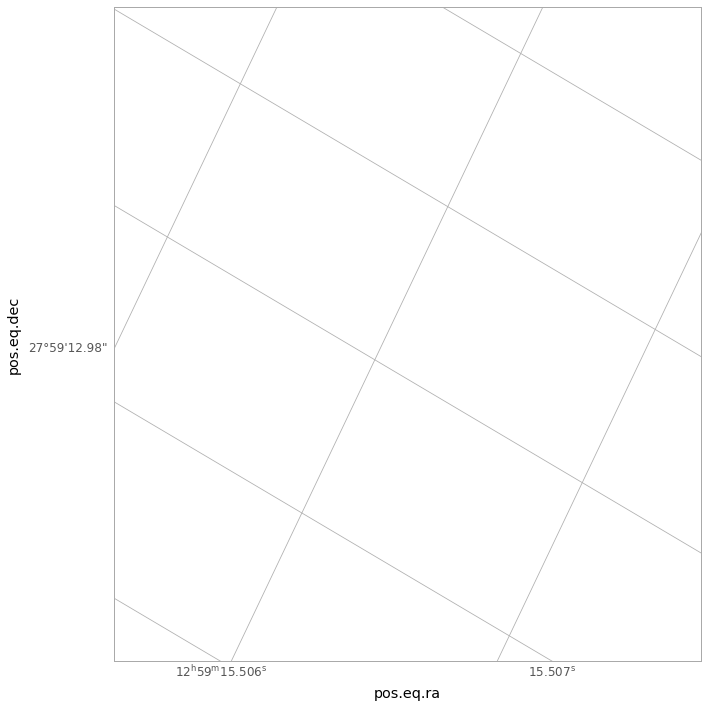

In [18]:

fig, axes = plt.subplots(subplot_kw={'projection': wcs}, figsize=(10, 10))

# Apply asinh scaling using ImageNormalize and AsinhStretch
norm = ImageNormalize(stretch=AsinhStretch(), vmin=np.percentile(image_data, 0.3), 
                      vmax=np.percentile(image_data, 99.6))
#                       vmin=np.min(image_data), vmax=np.max(image_data))

# Display the image
ax.imshow(image_data, origin='lower', cmap='gray_r', norm=norm)
#                vmin=np.percentile(image_data, 5), 
#                vmax=np.percentile(image_data, 95))

# Set axis labels to RA/Dec
ax.set_xlabel('Right Ascension (J2000)')
ax.set_ylabel('Declination (J2000)')

# Set title for each subplot to indicate the file
ax.set_title(f'Image: {fits_file_path}')

pix_lim = ax.get_xlim()
ax.set_xlim(pix_lim[1], pix_lim[0])

# Adjust the ticks and tick labels if necessary
# ax.coords[0].set_major_formatter('dd:mm')
# ax.coords[1].set_major_formatter('dd:mm')
# ax.tick_params(axis='both', which='major', labelsize=11, direction='out', length=3)
# Explicitly set the number of ticks
ax.coords[0].set_ticks(spacing=10 * u.arcsec)  # Set 5 RA ticks with 0.01 degree spacing
ax.coords[1].set_ticks(spacing=10 * u.arcsec)  # Set 5 Dec ticks with 0.01 degree spacing

# Adjust layout
plt.tight_layout()

# Display the grid of images
plt.show()


In [19]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp
import numpy as np
from astropy.visualization import astropy_mpl_style

# Apply Astropy's default plot style
plt.style.use(astropy_mpl_style)

# File paths to the FITS files
fits_file_path = ['HST_fits/h_v16_F814W_ivm_drz_cl_ver2.fits',
                  'HST_fits/h_v09_F814W_ivm_drz_cl_ver2.fits']
hdu = []
wcs = []
image_data = []

# Load the FITS files, extract WCS and data
for i, file in enumerate(fits_file_path):
    print(i, ", ", file)
    hdu.append(fits.open(file)[1])
    wcs.append(WCS(hdu[i].header))
    image_data.append(hdu[i].data)
            
# Set up a grid for displaying the images: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Loop through the images and display them with their native WCS in the grid
for i, ax in enumerate(axes):
    # Create a new axis with its own WCS projection
    ax = plt.subplot(1, 2, i + 1, projection=wcs[i])

    if i == 0:
        image = image_data[0] 
    else:
        # Reproject the second image to the WCS of the first image (only for combining later)
        image, footprint = reproject_interp((image_data[i], wcs[i]), wcs[0], shape_out=image_data[0].shape)

    # Display the image in its own WCS grid
    ax.imshow(image, origin='lower', cmap='gray_r', 
              vmin=np.percentile(image_data[i], 5), 
              vmax=np.percentile(image_data[i], 95))    
#     ax.imshow(image_data[i], origin='lower', cmap='gray_r', 
#               vmin=np.percentile(image_data[i], 5), 
#               vmax=np.percentile(image_data[i], 95))
    
    # Set axis labels to RA/Dec
    ax.set_xlabel('Right Ascension (J2000)')
    ax.set_ylabel('Declination (J2000)')
    
    # Set title for each subplot to indicate the file
    ax.set_title(f'Image {i+1}: {fits_file_path[i]}')
    
    pix_lim = ax.get_xlim()
#     ax.set_xlim(pix_lim[1], pix_lim[0])

    # Adjust the ticks and tick labels if necessary
    # ax.coords[0].set_major_formatter('dd:mm')
    # ax.coords[1].set_major_formatter('dd:mm')
    # ax.tick_params(axis='both', which='major', labelsize=11, direction='out', length=3)
    # Explicitly set the number of ticks
    ax.coords[0].set_ticks(spacing=10 * u.arcsec)  # Set 5 RA ticks with 0.01 degree spacing
    ax.coords[1].set_ticks(spacing=10 * u.arcsec)  # Set 5 Dec ticks with 0.01 degree spacing

# Adjust layout
plt.tight_layout()

# Display the grid of images
plt.show()


0 ,  HST_fits/h_v16_F814W_ivm_drz_cl_ver2.fits


FileNotFoundError: [Errno 2] No such file or directory: 'HST_fits/h_v16_F814W_ivm_drz_cl_ver2.fits'

### Exploring the FITS for NGC 4889

Found this image on the MAST site

https://mast.stsci.edu/search/ui/#/hst/results?resolve=true&target=NGC%204889&data_type=image&observations=S&active_instruments=acs,wfc3&legacy_instruments=wfpc2&proposal_id=10861,11711&radius=3&radius_units=arcminutes&useStore=false&search_key=4b79cb61f8e73

under the Blakeslee proposal.

Should have image data in but struggling to extract!

In [24]:
from astropy.io import fits

# Open the FITS file
fits_file = 'HST_fits/jb2i02020_drc_NGC4889.fits'

# Use 'with' to open the file and ensure it's closed properly after inspection
with fits.open(fits_file) as hdul:
    # Print out the structure of the FITS file
    hdul.info()


Filename: HST_fits/jb2i02020_drc_NGC4889.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1113   ()      
  1  SCI           1 ImageHDU        81   (4236, 4298)   float32   
  2  WHT           1 ImageHDU        44   (4236, 4298)   float32   
  3  CTX           1 ImageHDU        37   (4236, 4298)   int32   
  4  HDRTAB        1 BinTableHDU    593   24R x 292C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, 4A, 9A, 7A, 18A, 4A, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, 8A, 23A, D, D, D, D, K, K, K, 8A, K, 23A, 9A, 20A, K, 4A, K, D, K, K, K, K, 23A, D, D, D, D, K, K, 3A, 3A, 4A, 4A, L, D, D, D, 3A, 1A, K, D, D, D, 13A, 3A, 4A, 4A, 12A, 12A, 23A, 8A, 23A, 10A, 10A, D, D, 3A, 3A, 23A, 4A, 8A, 7A, 23A, D, K, D, 6A, 9A, 8A, D, D, L, 4A, 18A, 3A, K, 7A, 5A, 3A, D, 13A, 8A, 4A, 3A, L, K, L, K, L, K, K, D, D, D, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, 23A, L, 1A, 3A, 6A, D, 3A, 6A, K, D, D, D, D, D, D, D, D, D, D, 23A, D, D,

In [11]:
# Open the file and explore headers of each HDU
with fits.open(fits_file) as hdul:
    # Print the primary header (first HDU)
    print("Primary HDU header:")
    print(hdul[0].header)

    # If there's another HDU with image data, you can explore that too
    for i in range(1, len(hdul)):
        print(f"\nHDU {i} ({hdul[i].name}) header:")
        print(hdul[i].header)


Primary HDU header:
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  DATE    = '2024-01-04'         / date this file was written (yyyy-mm-dd)        COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H                                                                                 TELESCOP= 'HST'                / telescope used to acquire data                 INSTRUME= 'ACS   '             / identifier for instrument used to acquire data                                                                                               / DATA DESCRIPTION KEYWORDS                                                           

In [28]:
with fits.open(fits_file) as hdul:
    # Access the data in the primary HDU 
    image_data = hdul[1].data
    wcs = WCS(hdu[1].header)

    # Check if the data is loaded properly
    if image_data is None:
        print("No image data found in this HDU.")
    else:
        print(f"Image data shape: {image_data.shape}")

print(np.min(image_data), np.max(image_data))


INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
Image data shape: (4

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


Min value: nan
Max value: nan
Mean value: nan
Std dev: nan


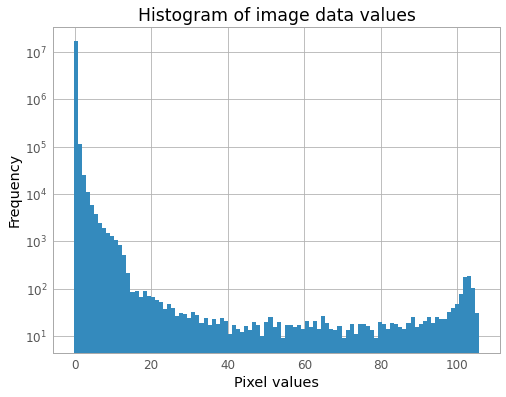

In [29]:
# Check basic statistics of the data
print(f"Min value: {np.min(image_data)}")
print(f"Max value: {np.max(image_data)}")
print(f"Mean value: {np.mean(image_data)}")
print(f"Std dev: {np.std(image_data)}")

# Optionally, plot a histogram of the data to see the distribution
plt.hist(image_data.flatten(), bins=100, log=True)
plt.title('Histogram of image data values')
plt.xlabel('Pixel values')
plt.ylabel('Frequency')
plt.show()


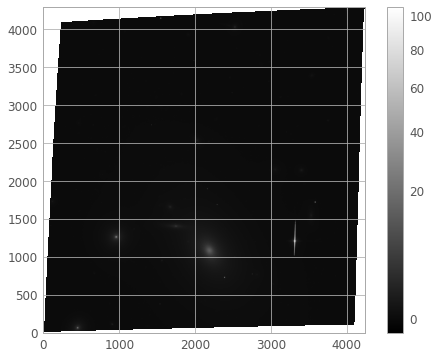

In [30]:
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

# Check if the image_data is valid
if image_data is not None:
    # Apply a simple normalization for better contrast
    norm = simple_norm(image_data, 'sqrt')

    # Display the image
    plt.imshow(image_data, origin='lower', cmap='gray', norm=norm)
    plt.colorbar()
    plt.show()
else:
    print("No valid image data found.")


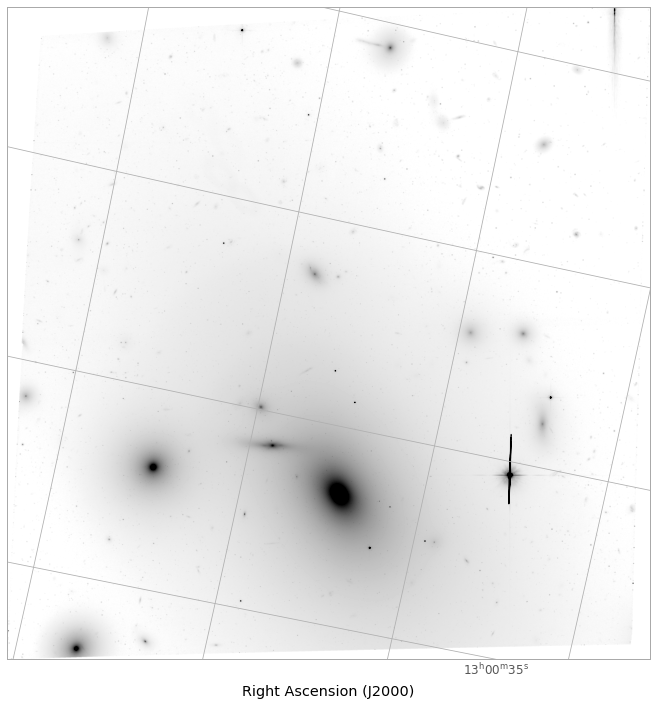

In [47]:


import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize, SqrtStretch, LogStretch, AsinhStretch
from astropy.wcs import WCS
from astropy.io import fits
from reproject import reproject_interp

# Replace NaN values with 0 (or use np.nanmin(image_data) for the minimum value)
image_data_clean = np.nan_to_num(image_data, np.nanmin(image_data))

# Now apply clipping to ensure no negative values
clipped_data = np.clip(image_data_clean, 0, None)

# Apply square root scaling with ImageNormalize
norm = ImageNormalize(clipped_data, stretch=SqrtStretch(), 
                      vmin=np.percentile(clipped_data, 0.01), 
                      vmax=np.percentile(clipped_data, 99.9))
# Normalize the image using AsinhStretch for better contrast
# norm = ImageNormalize(clipped_data, stretch=AsinhStretch(), 
#                       vmin=np.percentile(clipped_data, 70), 
#                       vmax=np.percentile(clipped_data, 100))

# Display the image with WCS and AsinhStretch
fig, ax = plt.subplots(subplot_kw={'projection': wcs}, figsize=(12, 12))
im = ax.imshow(clipped_data, origin='lower', cmap='gray_r', norm=norm)

# Set WCS axes labels
ax.set_xlabel('Right Ascension (J2000)')
ax.set_ylabel('Declination (J2000)')

# Show the plot
# plt.colorbar(im, ax=ax)
plt.show()




In [32]:
print(wcs)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 195.1156226  28.02846242  
CRPIX : 2116.701951  2158.498009  
CD1_1 CD1_2  : -2.898961744e-06  -1.359994784e-05  
CD2_1 CD2_2  : -1.358830134e-05  2.875037186e-06  
NAXIS : 4225  4300


In [33]:
#inFileName = "allpointings_master.dat_NoOverlap"
inFileName = "data/newallpointingsmaster_26may2021.dat"
inFile = open(inFileName, 'r')
lines = inFile.readlines()
inFile.close

data = pd.read_csv(inFileName, delimiter=' ')



In [34]:
# Define the range for UCD 'color' and 'mag_814'
ucd_color_min, ucd_color_max = 1.3, 2.1     #
ucd_mag_814_min, ucd_mag_814_max = 0, 22.9  # should be 0 mag to 22.9 mag

# remove duplicated data
data = data.drop_duplicates()

# Filter the DataFrame
gcs_df = data[(data['color'] <= ucd_color_min) | (data['color'] >= ucd_color_max) |
                 (data['mag_814'] <= ucd_mag_814_min) | (data['mag_814'] >= ucd_mag_814_max)]
ucd_df = data[(data['color'] > ucd_color_min) & (data['color'] < ucd_color_max) &
                 (data['mag_814'] > ucd_mag_814_min) & (data['mag_814'] < ucd_mag_814_max)]



[16.  18.3 20.6 22.9]
[16.   20.6  21.75 22.9 ]
Count for bin 1: 87
Number of duplicate rows (all columns): 0
Number of duplicate rows (RA & Dec & 814): 0
Removing duplicates
Data for bin between 16.0 and 20.6:
Count for bin 1: 87



/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))


Count for bin 2: 127
Number of duplicate rows (all columns): 0
Number of duplicate rows (RA & Dec & 814): 0
Removing duplicates
Data for bin between 20.6 and 21.75:
Count for bin 2: 127



/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))


Count for bin 3: 457
Number of duplicate rows (all columns): 0
Number of duplicate rows (RA & Dec & 814): 0
Removing duplicates
Data for bin between 21.75 and 22.9:
Count for bin 3: 457



/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
<ipython-input-35-9047db8f14e5>:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/

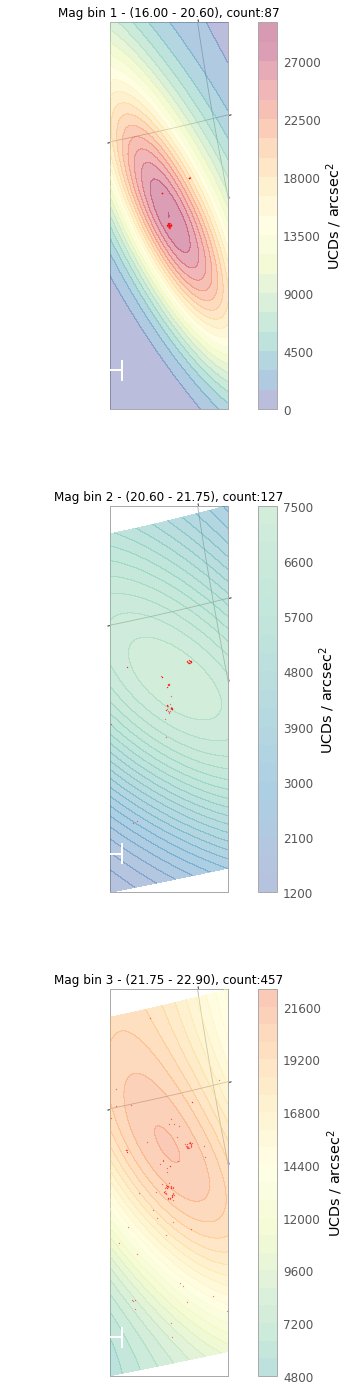

/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input

Created Coma_UCDs_size_profile_zoom.png


In [35]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter  # Import Gaussian filter

# Assuming wcs, image_data, and ucd_df are already defined

rows = 3; cols = 1; bin_limits = (rows * cols) + 1
width = 13.5 * cols; height = 8.3 * rows

# Define magnitude bin limits
mag_bins = np.linspace(16.0, 22.9, bin_limits)  # Set Mag limits for bins and number of limits (bins +1)
print(mag_bins)
mag_bins = np.ndarray(shape=(1,4), buffer=np.array([16.0, 20.6, 21.75, 22.9]), dtype=float)
mag_bins = np.array([16.0, 20.6, 21.75, 22.9])
print(mag_bins)


# Prepare to find global min and max for KDE
global_min = float('inf')
global_max = float('-inf')

# Prepare to find global min and max for KDE density
global_min_density = float('inf')
global_max_density = float('-inf')

# Define the area of each pixel in square degrees specific to WCS
pixel_scale = 0.0002 * 3600  # Example: 1 arcsec per pixel (was to degrees without '* 3600')
pixel_area = pixel_scale ** 2  # Square arcsecond per pixel

ra_min, ra_max, dec_min, dec_max = get_wcs_range(wcs, image_data)

# First pass to calculate global min and max
for i in range(rows):
    for j in range(cols):
        
#         # Calculate the index for the bin
#         bindex = j + (i * cols)

#         # Check if bindex is within the number of bins minus 1 (it should be!)
#         if bindex >= len(mag_bins) - 1:
#             continue

#         # Define the bin start and end
#         bin_start = mag_bins[bindex]
#         bin_end = mag_bins[bindex + 1]
        
        bindex, bin_start, bin_end = bin_init (i, j, mag_bins)

        # Filter the DataFrame for the current bin
        filtered_df = ucd_df[(ucd_df['mag_814'] > bin_start) & (ucd_df['mag_814'] <= bin_end)]

        # Check if there are enough data points for KDE
        if len(filtered_df) > 1:
            # Compute KDE manually
            kde = gaussian_kde([filtered_df['x_wcs'], filtered_df['y_wcs']])
            xgrid = np.linspace(ra_min, ra_max, 300)
            ygrid = np.linspace(dec_min, dec_max, 300)
            X, Y = np.meshgrid(xgrid, ygrid)
            Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
            
#             # Update global min and max
#             global_min = min(global_min, Z.min())
#             global_max = max(global_max, Z.max())
            
            # Convert to physical units (objects per square degree)
            Z_density = Z * len(filtered_df) / pixel_area
            
            # Optional: Apply Gaussian filter to smooth the density plot
            Z_density_smoothed = gaussian_filter(Z_density, sigma=1)

            # Update global min and max
            global_min_density = min(global_min_density, Z_density_smoothed.min())
            global_max_density = max(global_max_density, Z_density_smoothed.max())

# Create a figure
fig = plt.figure(figsize=(width, height))  # Figure size needs to be set for row / cols

# Create a 3x3 GridSpec
gs = GridSpec(3, 1, figure=fig, wspace=0.25, hspace=0.25)  # 

min_bin_count = 50
bin_count = 400

r = 0
# Loop through each subplot position in the GridSpec
for i in range(rows):
    for j in range(cols):

        bindex, bs, bin_end = bin_init (i, j, mag_bins)
        if bindex==0 or bin_count>min_bin_count:
            bin_start = bs
        consolidate = False if bin_count>min_bin_count else True

        # Filter the DataFrame for the current bin
        filtered_df = ucd_df[(ucd_df['mag_814'] > bin_start) & (ucd_df['mag_814'] <= bin_end)]
        bin_count = len(filtered_df['mag_814'])

        # Debugging print to check the filtered data
        print(f"Count for bin {bindex+1}: {bin_count}" )

        duplicate_count = filtered_df.duplicated().sum()
        print(f"Number of duplicate rows (all columns): {duplicate_count}")
        duplicates = filtered_df.duplicated(subset=['x_wcs', 'y_wcs', 'mag_814'])
        print(f"Number of duplicate rows (RA & Dec & 814): {duplicate_count}")
        print("Removing duplicates")
        filtered_df = filtered_df.drop_duplicates()

        print(f"Data for bin between {bin_start} and {bin_end}:")
#         for index, row in filtered_df.iterrows():
#             print(f"RA: {row['x_wcs']}, Dec:{row['y_wcs']}, Mag 814: {row['mag_814']}")
        bin_count = len(filtered_df['mag_814'])
        print(f"Count for bin {bindex+1}: {bin_count}" )
        print()
        
        if not consolidate:
            # Display the image with WCS and AsinhStretch
#             fig, ax = plt.subplots(subplot_kw={'projection': wcs}, figsize=(12, 12))
            # Create subplot at each position with WCS projection
            ax = fig.add_subplot(gs[r, 0], projection=wcs)
            r = r + 1

            # Display the image
            im = ax.imshow(clipped_data, origin='lower', cmap='gray_r', norm=norm)
#             ax.imshow(image_data, origin='lower', cmap='gray_r',
#                       vmin=np.percentile(image_data, 5), 
#                       vmax=np.percentile(image_data, 95))

            # Set the axis labels to RA/Dec
            ax.set_xlabel('R.A. (J2000, deg)') if i==(rows-1) else ax.set_xlabel(' ')
            ax.set_ylabel('Dec (J2000, deg)') if j==0 else ax.set_ylabel(' ')

            # Adjust the ticks and tick labels if necessary
            ax.coords[0].set_major_formatter('dd:mm')
            ax.coords[1].set_major_formatter('dd:mm')
            ax.tick_params(axis='both', which='major', labelsize=11, direction='out', length=3)

            # **Check if there are enough data points for KDE**
            if len(filtered_df) > 1 :  # KDE requires at least 2 data points
                kde = gaussian_kde([filtered_df['x_wcs'], filtered_df['y_wcs']])
                xgrid = np.linspace(ra_min, ra_max, 300)
                ygrid = np.linspace(dec_min, dec_max, 300)
                X, Y = np.meshgrid(xgrid, ygrid)
                Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
                Z_density = Z * len(filtered_df) / pixel_area

                # Optional: Apply Gaussian filter to smooth the density plot
                Z_density_smoothed = gaussian_filter(Z_density, sigma=0.7)
                global_min_density = 1
                contour = ax.contourf(X, Y, Z_density, levels=20, cmap="Spectral_r", alpha=0.4, extend='neither',
                                      vmin=global_min_density, vmax=global_max_density, transform=ax.get_transform('world'))

                # Add colorbar for this subplot
                cbar = fig.colorbar(contour, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
                cbar.set_label(r'UCDs / arcsec$^2$')

                ax.scatter(filtered_df['x_wcs'], filtered_df['y_wcs'], 
                           transform=ax.get_transform('world'), 
                           marker = '.', s=0.2, alpha = 1, color = 'red')
                # Explicitly set the number of ticks
                ax.coords[0].set_ticks(spacing=10 * u.arcmin)  # Set 5 RA ticks with 0.01 degree spacing
                ax.coords[1].set_ticks(spacing=10 * u.arcmin)  # Set 5 Dec ticks with 0.01 degree spacing

            # Set subplot title
            ax.set_title(f"Mag bin {bindex+1} - ({bin_start:5.2f} - {bin_end:5.2f}), count:{bin_count}", fontsize=12)

            # Set desired limits in WCS (RA, Dec)
            ra_min, ra_max = 195.28, 194.74  # RA limits in degrees
            dec_min, dec_max = 27.805, 28.19  # Dec limits in degrees

            # Set desired limits in WCS (RA, Dec)
            ra_min, ra_max = 195.10, 194.97  # RA limits in degrees
            dec_min, dec_max = 27.94, 28.01  # Dec limits in degrees

            pix_min = wcs.world_to_pixel_values(ra_min, dec_min)
            pix_max = wcs.world_to_pixel_values(ra_max, dec_max)

            # Set pixel limits directly
            ax.set_xlim(pix_min[0], pix_max[0])
            ax.set_ylim(pix_min[1], pix_max[1])
            
            # Add a scale marker (e.g., 60 arcseconds = 1 arcminute)
            length_arcsec = get_angular_sep(25e3, 100e6)
            add_scale_bar(ax, wcs, length_arcsec=length_arcsec, label="25 kpc", color='white', fontsize=11)        

# Adjust layout
fig.tight_layout()
# Show the figure
plt.show()

figname = f'Coma_UCDs_size_profile_zoom.png'
# save and show the plot
fig.savefig(figname, bbox_inches='tight', format='png', dpi=300)  # bbox_inches='tight',
plt.close()
print("Created {f}".format(f=figname))



[16.  22.9]
RA (min, max):  195.28 194.74 , Dec (min, max):  27.805 28.19
Count for bin 1: 671
Number of duplicate rows (all columns): 0
Number of duplicate rows (RA & Dec & 814): 0
Removing duplicates
Data for bin between 16.0 and 22.9:
Count for bin 1: 671



/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 2 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
<ipython-input-46-75291505b2cd>:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))


Pix (min RA,Dec): (array(13448.73483172), array(-9765.60610914)) Pix (max RA,Dec): (array(-18124.64774094), array(42783.9825044))


/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input

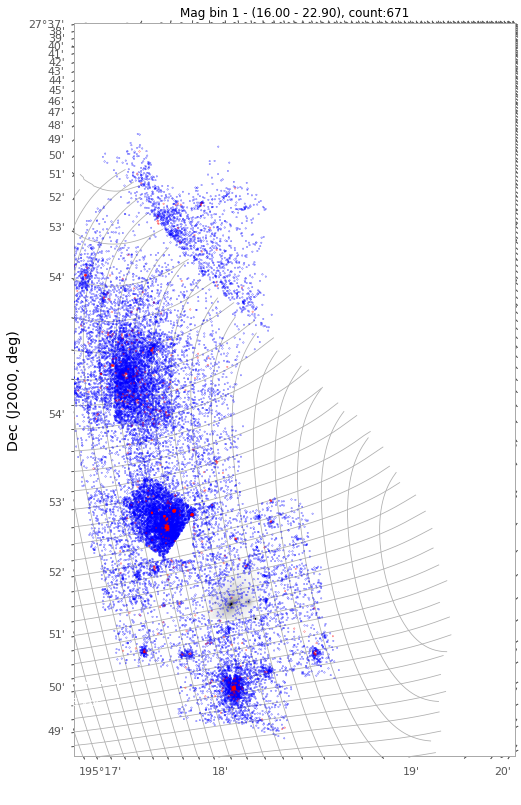

/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input point.
  warnings.warn(str(e))
/opt/anaconda3/lib/python3.8/site-packages/astropy/wcs/wcsapi/fitswcs.py:347: UserWarning: 'WCS.all_world2pix' failed to converge to the requested accuracy.
After 20 iterations, the solution is diverging at least for one input

Created Coma_UCD_GCs_NGC_4889_zoom_rot.png


In [46]:
from matplotlib.gridspec import GridSpec
from scipy.ndimage import rotate

########################### define rotation matrix from FITS HDUL header
CD1_1 = 9.57809217305804e-06
CD1_2 = -1.0057901614765e-05
CD2_1 = -1.0057901614765e-05
CD2_2 = -9.578092173058e-06

# Assuming wcs, image_data, and ucd_df are already defined

rows = 1; cols = 1; bin_limits = (rows * cols) + 1
width = 13.5 * cols; height = 13.5 * rows

# Define magnitude bin limits
mag_bins = np.array([16.0, 22.9])
print(mag_bins)

# Define the area of each pixel in square degrees specific to WCS
pixel_scale = 0.0002 * 3600  # Example: 1 arcsec per pixel (was to degrees without '* 3600')
pixel_area = pixel_scale ** 2  # Square arcsecond per pixel

ra_min, ra_max, dec_min, dec_max = get_wcs_range(wcs, image_data)
print('RA (min, max): ', ra_min, ra_max, ', Dec (min, max): ', dec_min, dec_max)
# Create a figure
fig = plt.figure(figsize=(width, height))  # Figure size needs to be set for row / cols

# Create a 3x3 GridSpec
gs = GridSpec(1, 1, figure=fig, wspace=0.25, hspace=0.25)  # 

bindex, bin_start, bin_end = bin_init (0, 0, mag_bins)

#######################################################################
# Filter the DataFrame for the current bin
filtered_df = ucd_df[(ucd_df['mag_814'] > bin_start) & (ucd_df['mag_814'] <= bin_end)]
bin_count = len(filtered_df['mag_814'])

# Debugging print to check the filtered data
print(f"Count for bin {bindex+1}: {bin_count}" )

duplicate_count = filtered_df.duplicated().sum()
print(f"Number of duplicate rows (all columns): {duplicate_count}")
duplicates = filtered_df.duplicated(subset=['x_wcs', 'y_wcs', 'mag_814'])
print(f"Number of duplicate rows (RA & Dec & 814): {duplicate_count}")
print("Removing duplicates")
filtered_df = filtered_df.drop_duplicates()

print(f"Data for bin between {bin_start} and {bin_end}:")
#         for index, row in filtered_df.iterrows():
#             print(f"RA: {row['x_wcs']}, Dec:{row['y_wcs']}, Mag 814: {row['mag_814']}")
bin_count = len(filtered_df['mag_814'])
print(f"Count for bin {bindex+1}: {bin_count}" )
print()

# Apply square root scaling with ImageNormalize
norm = ImageNormalize(clipped_data, stretch=SqrtStretch(), 
                      vmin=np.percentile(clipped_data, 0.05), 
                      vmax=np.percentile(clipped_data, 99.9))
# Normalize the image using AsinhStretch for better contrast
# norm = ImageNormalize(clipped_data, stretch=AsinhStretch(), 
#                       vmin=np.percentile(clipped_data, 1), 
#                       vmax=np.percentile(clipped_data, 99.999))

# Calculate the rotation angle from the CD matrix
rotation_angle = np.degrees(np.arctan2(CD1_2, CD1_1))
# rotation_angle = 0

# Rotate the image to align with RA-Dec
# rotated_data = rotate(clipped_data, angle=-rotation_angle, reshape=False)

#######################################################################
# Create subplot at each position with WCS projection
ax = fig.add_subplot(gs[0, 0], projection=wcs)

# show the image
im = ax.imshow(clipped_data, origin='lower', cmap='gray_r', norm=norm)

# Set the axis labels to RA/Dec
ax.set_xlabel('R.A. (J2000, deg)') if i==(rows-1) else ax.set_xlabel(' ')
ax.set_ylabel('Dec (J2000, deg)') if j==0 else ax.set_ylabel(' ')

# Adjust the ticks and tick labels if necessary
ax.coords[0].set_major_formatter('dd:mm')
ax.coords[1].set_major_formatter('dd:mm')
ax.tick_params(axis='both', which='major', labelsize=11, direction='out', length=3)

# xgrid = np.linspace(ra_min, ra_max, 300)
# ygrid = np.linspace(dec_min, dec_max, 300)
# X, Y = np.meshgrid(xgrid, ygrid)

offset_ra = -0.000051
offset_dec = 0.000049

ax.scatter(gcs_df['x_wcs']+offset_ra, gcs_df['y_wcs']+offset_dec, 
           transform=ax.get_transform('world'), 
           marker = 'o', s=2, alpha = 1, color = 'blue', linewidth=0.3, facecolor='none')
ax.scatter(filtered_df['x_wcs']+offset_ra, filtered_df['y_wcs']+offset_dec, 
           transform=ax.get_transform('world'), 
           marker = 'o', s=2, alpha = 1, edgecolor = 'red', linewidth=0.3, facecolor='none')
# Explicitly set the number of ticks
ax.coords[0].set_ticks(spacing=1 * u.arcmin)  # Set 5 RA ticks with 0.01 degree spacing
ax.coords[1].set_ticks(spacing=1 * u.arcmin)  # Set 5 Dec ticks with 0.01 degree spacing

# Set subplot title
ax.set_title(f"Mag bin {bindex+1} - ({bin_start:5.2f} - {bin_end:5.2f}), count:{bin_count}", fontsize=12)

# Set desired limits in WCS (RA, Dec)
ra_min, ra_max = 195.28, 194.74  # RA limits in degrees
dec_min, dec_max = 27.805, 28.19  # Dec limits in degrees

#             # Set desired limits in WCS (RA, Dec)
# ra_min, ra_max = 195.09, 194.95  # RA limits in degrees
# dec_min, dec_max = 27.97, 27.97  # Dec limits in degrees
# ra_min, ra_max = 195.10, 194.97  # RA limits in degrees
# dec_min, dec_max = 27.90, 28.06  # Dec limits in degrees

pix_min = wcs.world_to_pixel_values(ra_min, dec_min)
pix_max = wcs.world_to_pixel_values(ra_max, dec_max)

print('Pix (min RA,Dec):', pix_min, 'Pix (max RA,Dec):', pix_max)
#             # Set pixel limits directly
ax.set_xlim(pix_min[0], pix_max[0])
ax.set_ylim(pix_min[1], pix_max[1])  

# Add a scale marker (e.g., 60 arcseconds = 1 arcminute)
length_arcsec = get_angular_sep(25e3, 100e6)
add_scale_bar(ax, wcs, length_arcsec=length_arcsec, label="25 kpc", color='white', fontsize=11)        
    
# Adjust layout
fig.tight_layout()
# Show the figure
plt.show()

figname = f'Coma_UCD_GCs_NGC_4889_zoom_rot.png'
# save and show the plot
fig.savefig(figname, bbox_inches='tight', format='png', dpi=600)  # bbox_inches='tight',
plt.close()
print("Created {f}".format(f=figname))

